In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm



In [2]:
# ---------- CONFIG ----------
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
EPOCHS = 10  # Reduced for speed, sufficient to detect collapse
BATCH = 256
LR = 1e-3


Running Phase Transition Study on cpu
Running Experiment 1: Depth vs. Collapse...


Depth Sweep (MNIST): 100%|████████████████████████| 8/8 [04:19<00:00, 32.41s/it]



Running Experiment 2: Width vs. Recovery...


Depth Sweep (MNIST): 100%|███████████████████████| 1/1 [04:26<00:00, 266.37s/it]



Running Experiment 3: Data Complexity...


Depth Sweep (CIFAR10): 100%|██████████████████████| 8/8 [05:00<00:00, 37.56s/it]


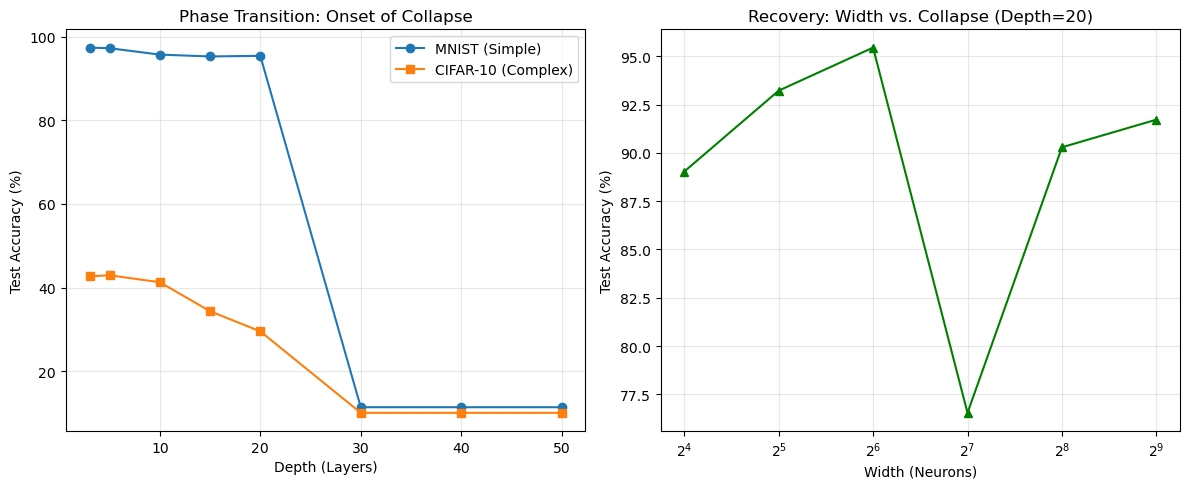


DATA FOR PLOT 1: Phase Transition (Depth)
dataset  depth  accuracy
  MNIST      3     97.42
  MNIST      5     97.27
  MNIST     10     95.74
  MNIST     15     95.30
  MNIST     20     95.45
  MNIST     30     11.35
  MNIST     40     11.35
  MNIST     50     11.35
CIFAR10      3     42.68
CIFAR10      5     42.93
CIFAR10     10     41.26
CIFAR10     15     34.32
CIFAR10     20     29.51
CIFAR10     30     10.00
CIFAR10     40     10.00
CIFAR10     50     10.00

DATA FOR PLOT 2: Recovery (Width)
dataset  depth  width  accuracy
  MNIST     20     16     89.03
  MNIST     20     32     93.22
  MNIST     20     64     95.45
  MNIST     20    128     76.54
  MNIST     20    256     90.29
  MNIST     20    512     91.72


In [3]:
print(f"Running Phase Transition Study on {DEVICE}")

# ---------- DATA LOADERS ----------
def get_loaders(dataset_name):
    if dataset_name == 'MNIST':
        transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
        train_set = datasets.MNIST('./data', train=True, download=True, transform=transform)
        test_set = datasets.MNIST('./data', train=False, transform=transform)
        input_dim = 28 * 28
        in_channels = 1
    elif dataset_name == 'CIFAR10':
        transform = transforms.Compose([
            transforms.Grayscale(), # Simplify to 1 channel to keep MLP comparable
            transforms.ToTensor(), 
            transforms.Normalize((0.5,), (0.5,))
        ])
        train_set = datasets.CIFAR10('./data', train=True, download=True, transform=transform)
        test_set = datasets.CIFAR10('./data', train=False, transform=transform)
        input_dim = 32 * 32
        in_channels = 1
    
    train = DataLoader(train_set, batch_size=BATCH, shuffle=True)
    test = DataLoader(test_set, batch_size=BATCH, shuffle=False)
    return train, test, input_dim

# ---------- DYNAMIC MLP ----------
class DynamicMLP(nn.Module):
    def __init__(self, depth, width, input_dim, num_classes=10):
        super().__init__()
        layers = [nn.Flatten(), nn.Linear(input_dim, width), nn.ReLU()]
        for _ in range(depth - 2):
            layers.append(nn.Linear(width, width))
            layers.append(nn.ReLU())
        layers.append(nn.Linear(width, num_classes))
        self.net = nn.Sequential(*layers)
        
    def forward(self, x): return self.net(x)

# ---------- METRICS ----------
def get_metrics(model, loader, criterion):
    model.eval()
    correct = 0
    total = 0
    loss_sum = 0
    
    # 1. Accuracy & Loss
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            out = model(x)
            loss_sum += criterion(out, y).item()
            _, pred = torch.max(out, 1)
            total += y.size(0)
            correct += (pred == y).sum().item()
    
    acc = 100 * correct / total
    
    # 2. Sharpness (Final Layer Hessian Top Eigenvalue)
    # Quick estimate using one batch
    params = [p for p in model.parameters() if p.requires_grad]
    if len(params) > 0:
        # Just grab the last layer parameters for speed/relevance
        last_layer = list(model.net.children())[-1]
        ll_params = list(last_layer.parameters())
        
        # Power Iteration
        v = [torch.randn_like(p) for p in ll_params]
        # Normalize
        v_norm = torch.sqrt(sum((vi**2).sum() for vi in v))
        v = [vi/v_norm for vi in v]
        
        iter_loader = iter(loader)
        x, y = next(iter_loader)
        x, y = x.to(DEVICE), y.to(DEVICE)
        
        # Single step hessian estim
        model.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        grads = torch.autograd.grad(loss, ll_params, create_graph=True)
        Hv = torch.autograd.grad(sum((g*vi).sum() for g, vi in zip(grads, v)), ll_params)
        sharpness = torch.sqrt(sum((h**2).sum() for h in Hv)).item()
    else:
        sharpness = 0.0

    return acc, sharpness

# ---------- EXPERIMENT RUNNER ----------
def run_experiment(depths, widths, dataset_name):
    results = []
    train_loader, test_loader, input_dim = get_loaders(dataset_name)
    criterion = nn.CrossEntropyLoss()
    
    # Grid Search
    for d in tqdm(depths, desc=f"Depth Sweep ({dataset_name})"):
        for w in widths:
            seed = 42
            torch.manual_seed(seed)
            model = DynamicMLP(d, w, input_dim).to(DEVICE)
            optimizer = optim.Adam(model.parameters(), lr=LR)
            
            # Train
            model.train()
            for _ in range(EPOCHS):
                for x, y in train_loader:
                    x, y = x.to(DEVICE), y.to(DEVICE)
                    optimizer.zero_grad()
                    loss = criterion(model(x), y)
                    loss.backward()
                    optimizer.step()
            
            # Measure
            acc, sharp = get_metrics(model, test_loader, criterion)
            
            results.append({
                'depth': d,
                'width': w,
                'dataset': dataset_name,
                'accuracy': acc,
                'sharpness': sharp
            })
            
    return pd.DataFrame(results)

# ---------- MAIN EXECUTION ----------
if __name__ == "__main__":
    
    # 1. DEPTH SWEEP (The Collapse Curve)
    # Vary depth significantly to find the "Cliff"
    depths_exp1 = [3, 5, 10, 15, 20, 30, 40, 50]
    widths_exp1 = [64] # Fixed width
    print("Running Experiment 1: Depth vs. Collapse...")
    df_depth = run_experiment(depths_exp1, widths_exp1, 'MNIST')
    
    # 2. WIDTH SWEEP (The Rescue Curve)
    # Pick a "semi-collapsed" depth (e.g., 20) and try to save it with width
    depths_exp2 = [20] 
    widths_exp2 = [16, 32, 64, 128, 256, 512]
    print("\nRunning Experiment 2: Width vs. Recovery...")
    df_width = run_experiment(depths_exp2, widths_exp2, 'MNIST')
    
    # 3. COMPLEXITY SWEEP
    # Compare MNIST vs CIFAR-10 on the Depth Curve
    print("\nRunning Experiment 3: Data Complexity...")
    df_cifar = run_experiment(depths_exp1, [64], 'CIFAR10')
    
    # Combined Data for Plotting
    full_df = pd.concat([df_depth, df_width, df_cifar], ignore_index=True)
    
    # ---------- PLOTTING ----------
    
    # Plot 1: The Phase Transition (Depth)
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    # Filter for Exp 1
    data_mnist = df_depth
    data_cifar = df_cifar
    
    plt.plot(data_mnist['depth'], data_mnist['accuracy'], marker='o', label='MNIST (Simple)')
    plt.plot(data_cifar['depth'], data_cifar['accuracy'], marker='s', label='CIFAR-10 (Complex)')
    plt.xlabel("Depth (Layers)")
    plt.ylabel("Test Accuracy (%)")
    plt.title("Phase Transition: Onset of Collapse")
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 2: Width Recovery
    plt.subplot(1, 2, 2)
    data_width = df_width
    plt.plot(data_width['width'], data_width['accuracy'], marker='^', color='green')
    plt.xlabel("Width (Neurons)")
    plt.ylabel("Test Accuracy (%)")
    plt.title("Recovery: Width vs. Collapse (Depth=20)")
    plt.xscale('log', base=2) # Width usually scales logarithmically
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # ---------- PRINT VALUES TABLES ----------
    print("\n" + "="*50)
    print("DATA FOR PLOT 1: Phase Transition (Depth)")
    print("="*50)
    # Combine specific columns for cleaner display
    plot1_disp = pd.concat([
        df_depth[['dataset', 'depth', 'accuracy']], 
        df_cifar[['dataset', 'depth', 'accuracy']]
    ])
    # Print without the pandas index for a cleaner table look
    print(plot1_disp.to_string(index=False))

    print("\n" + "="*50)
    print("DATA FOR PLOT 2: Recovery (Width)")
    print("="*50)
    plot2_disp = df_width[['dataset', 'depth', 'width', 'accuracy']]
    print(plot2_disp.to_string(index=False))

Running Phase Transition Study on cpu
Running Experiment 1: Depth vs. Collapse...


Depth Sweep (MNIST): 100%|████████████████████████| 8/8 [04:25<00:00, 33.22s/it]



Running Experiment 2: Width vs. Recovery...


Depth Sweep (MNIST): 100%|███████████████████████| 1/1 [04:24<00:00, 264.75s/it]



Running Experiment 3: Data Complexity...


Depth Sweep (CIFAR10): 100%|██████████████████████| 8/8 [04:55<00:00, 36.91s/it]


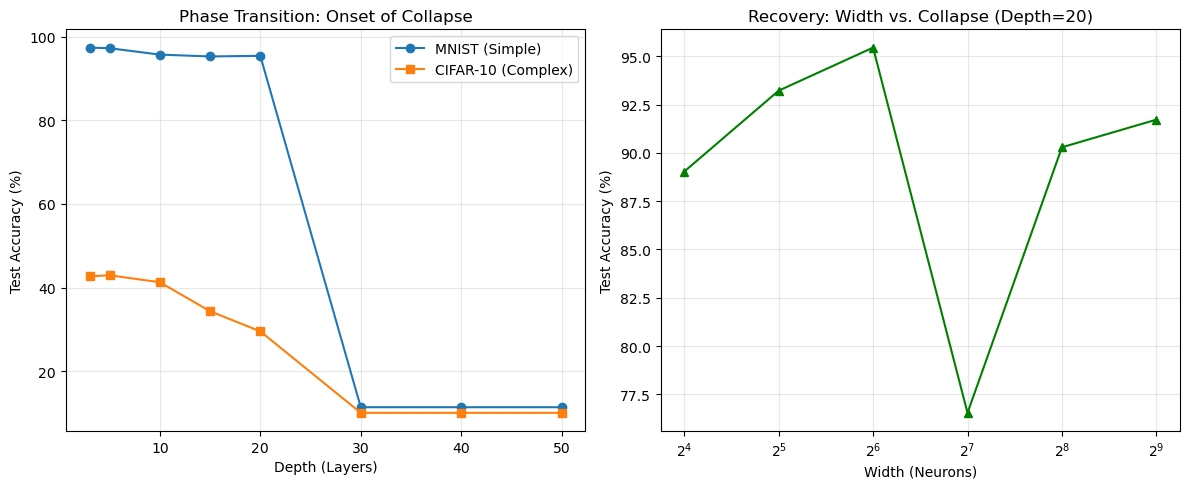


--- Summary Data ---
    depth  width  dataset  accuracy  sharpness
0       3     64    MNIST     97.42   0.339505
1       5     64    MNIST     97.27   0.214176
2      10     64    MNIST     95.74   0.570471
3      15     64    MNIST     95.30   3.963469
4      20     64    MNIST     95.45   0.624120
5      30     64    MNIST     11.35   0.009722
6      40     64    MNIST     11.35   0.012817
7      50     64    MNIST     11.35   0.016010
8      20     16    MNIST     89.03  43.807121
9      20     32    MNIST     93.22   7.803759
10     20     64    MNIST     95.45   0.624120
11     20    128    MNIST     76.54   3.793587
12     20    256    MNIST     90.29   0.838790
13     20    512    MNIST     91.72   0.254558
14      3     64  CIFAR10     42.68   0.460286
15      5     64  CIFAR10     42.93   0.679056
16     10     64  CIFAR10     41.26   0.705910
17     15     64  CIFAR10     34.32   0.510360
18     20     64  CIFAR10     29.51   0.251812
19     30     64  CIFAR10     10.00   

In [7]:

print(f"Running Phase Transition Study on {DEVICE}")

# ---------- DATA LOADERS ----------
def get_loaders(dataset_name):
    if dataset_name == 'MNIST':
        transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
        train_set = datasets.MNIST('./data', train=True, download=True, transform=transform)
        test_set = datasets.MNIST('./data', train=False, transform=transform)
        input_dim = 28 * 28
        in_channels = 1
    elif dataset_name == 'CIFAR10':
        transform = transforms.Compose([
            transforms.Grayscale(), # Simplify to 1 channel to keep MLP comparable
            transforms.ToTensor(), 
            transforms.Normalize((0.5,), (0.5,))
        ])
        train_set = datasets.CIFAR10('./data', train=True, download=True, transform=transform)
        test_set = datasets.CIFAR10('./data', train=False, transform=transform)
        input_dim = 32 * 32
        in_channels = 1
    
    train = DataLoader(train_set, batch_size=BATCH, shuffle=True)
    test = DataLoader(test_set, batch_size=BATCH, shuffle=False)
    return train, test, input_dim

# ---------- DYNAMIC MLP ----------
class DynamicMLP(nn.Module):
    def __init__(self, depth, width, input_dim, num_classes=10):
        super().__init__()
        layers = [nn.Flatten(), nn.Linear(input_dim, width), nn.ReLU()]
        for _ in range(depth - 2):
            layers.append(nn.Linear(width, width))
            layers.append(nn.ReLU())
        layers.append(nn.Linear(width, num_classes))
        self.net = nn.Sequential(*layers)
        
    def forward(self, x): return self.net(x)

# ---------- METRICS ----------
def get_metrics(model, loader, criterion):
    model.eval()
    correct = 0
    total = 0
    loss_sum = 0
    
    # 1. Accuracy & Loss
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            out = model(x)
            loss_sum += criterion(out, y).item()
            _, pred = torch.max(out, 1)
            total += y.size(0)
            correct += (pred == y).sum().item()
    
    acc = 100 * correct / total
    
    # 2. Sharpness (Final Layer Hessian Top Eigenvalue)
    # Quick estimate using one batch
    params = [p for p in model.parameters() if p.requires_grad]
    if len(params) > 0:
        # Just grab the last layer parameters for speed/relevance
        last_layer = list(model.net.children())[-1]
        ll_params = list(last_layer.parameters())
        
        # Power Iteration
        v = [torch.randn_like(p) for p in ll_params]
        # Normalize
        v_norm = torch.sqrt(sum((vi**2).sum() for vi in v))
        v = [vi/v_norm for vi in v]
        
        iter_loader = iter(loader)
        x, y = next(iter_loader)
        x, y = x.to(DEVICE), y.to(DEVICE)
        
        # Single step hessian estim
        model.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        grads = torch.autograd.grad(loss, ll_params, create_graph=True)
        Hv = torch.autograd.grad(sum((g*vi).sum() for g, vi in zip(grads, v)), ll_params)
        sharpness = torch.sqrt(sum((h**2).sum() for h in Hv)).item()
    else:
        sharpness = 0.0

    return acc, sharpness

# ---------- EXPERIMENT RUNNER ----------
def run_experiment(depths, widths, dataset_name):
    results = []
    train_loader, test_loader, input_dim = get_loaders(dataset_name)
    criterion = nn.CrossEntropyLoss()
    
    # Grid Search
    for d in tqdm(depths, desc=f"Depth Sweep ({dataset_name})"):
        for w in widths:
            seed = 42
            torch.manual_seed(seed)
            model = DynamicMLP(d, w, input_dim).to(DEVICE)
            optimizer = optim.Adam(model.parameters(), lr=LR)
            
            # Train
            model.train()
            for _ in range(EPOCHS):
                for x, y in train_loader:
                    x, y = x.to(DEVICE), y.to(DEVICE)
                    optimizer.zero_grad()
                    loss = criterion(model(x), y)
                    loss.backward()
                    optimizer.step()
            
            # Measure
            acc, sharp = get_metrics(model, test_loader, criterion)
            
            results.append({
                'depth': d,
                'width': w,
                'dataset': dataset_name,
                'accuracy': acc,
                'sharpness': sharp
            })
            
    return pd.DataFrame(results)

# ---------- MAIN EXECUTION ----------
if __name__ == "__main__":
    
    # 1. DEPTH SWEEP (The Collapse Curve)
    # Vary depth significantly to find the "Cliff"
    depths_exp1 = [3, 5, 10, 15, 20, 30, 40, 50]
    widths_exp1 = [64] # Fixed width
    print("Running Experiment 1: Depth vs. Collapse...")
    df_depth = run_experiment(depths_exp1, widths_exp1, 'MNIST')
    
    # 2. WIDTH SWEEP (The Rescue Curve)
    # Pick a "semi-collapsed" depth (e.g., 20) and try to save it with width
    depths_exp2 = [20] 
    widths_exp2 = [16, 32, 64, 128, 256, 512]
    print("\nRunning Experiment 2: Width vs. Recovery...")
    df_width = run_experiment(depths_exp2, widths_exp2, 'MNIST')
    
    # 3. COMPLEXITY SWEEP
    # Compare MNIST vs CIFAR-10 on the Depth Curve
    print("\nRunning Experiment 3: Data Complexity...")
    df_cifar = run_experiment(depths_exp1, [64], 'CIFAR10')
    
    # Combined Data for Plotting
    full_df = pd.concat([df_depth, df_width, df_cifar], ignore_index=True)
    
    # ---------- PLOTTING ----------
    
    # Plot 1: The Phase Transition (Depth)
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    # Filter for Exp 1
    data_mnist = df_depth
    data_cifar = df_cifar
    
    plt.plot(data_mnist['depth'], data_mnist['accuracy'], marker='o', label='MNIST (Simple)')
    plt.plot(data_cifar['depth'], data_cifar['accuracy'], marker='s', label='CIFAR-10 (Complex)')
    plt.xlabel("Depth (Layers)")
    plt.ylabel("Test Accuracy (%)")
    plt.title("Phase Transition: Onset of Collapse")
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 2: Width Recovery
    plt.subplot(1, 2, 2)
    data_width = df_width
    plt.plot(data_width['width'], data_width['accuracy'], marker='^', color='green')
    plt.xlabel("Width (Neurons)")
    plt.ylabel("Test Accuracy (%)")
    plt.title("Recovery: Width vs. Collapse (Depth=20)")
    plt.xscale('log', base=2) # Width usually scales logarithmically
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print raw data for inspection
    print("\n--- Summary Data ---")
    print(full_df)

Running Phase Transition Study on cpu
Running Experiment 1: Depth vs. Collapse...


Depth Sweep (MNIST): 100%|████████████████████████| 8/8 [04:28<00:00, 33.56s/it]



Running Experiment 2: Width vs. Recovery...


Depth Sweep (MNIST): 100%|███████████████████████| 1/1 [04:29<00:00, 269.53s/it]



Running Experiment 3: Data Complexity...


Depth Sweep (CIFAR10): 100%|██████████████████████| 8/8 [04:53<00:00, 36.72s/it]


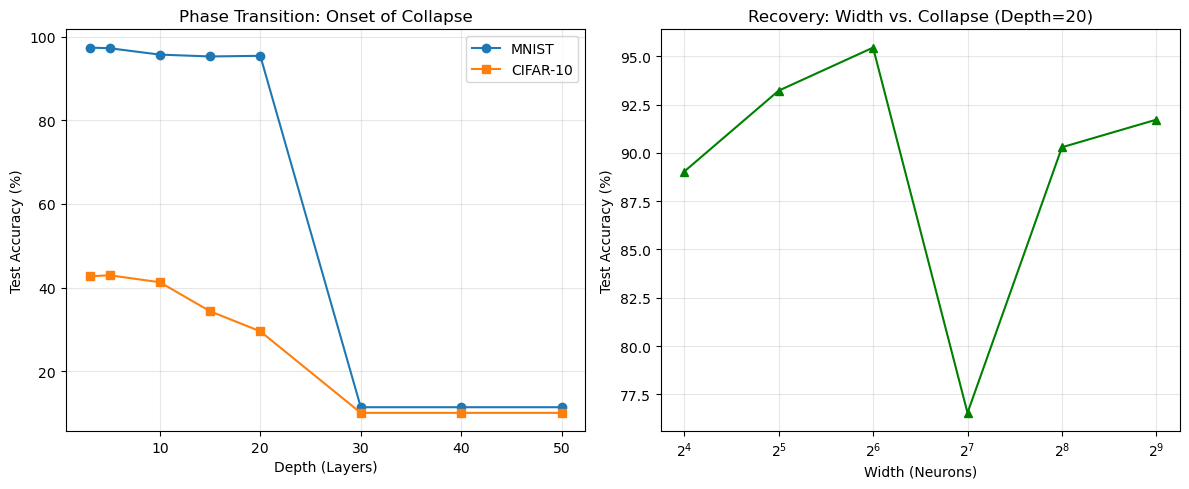


DATA FOR PLOT 1: Phase Transition (Depth)
dataset  depth  accuracy
  MNIST      3     97.42
  MNIST      5     97.27
  MNIST     10     95.74
  MNIST     15     95.30
  MNIST     20     95.45
  MNIST     30     11.35
  MNIST     40     11.35
  MNIST     50     11.35
CIFAR10      3     42.68
CIFAR10      5     42.93
CIFAR10     10     41.26
CIFAR10     15     34.32
CIFAR10     20     29.51
CIFAR10     30     10.00
CIFAR10     40     10.00
CIFAR10     50     10.00

DATA FOR PLOT 2: Recovery (Width)
dataset  depth  width  accuracy
  MNIST     20     16     89.03
  MNIST     20     32     93.22
  MNIST     20     64     95.45
  MNIST     20    128     76.54
  MNIST     20    256     90.29
  MNIST     20    512     91.72

FULL SUMMARY DATA (All Experiments)
    depth  width  dataset  accuracy  sharpness
0       3     64    MNIST     97.42   0.339505
1       5     64    MNIST     97.27   0.214176
2      10     64    MNIST     95.74   0.570471
3      15     64    MNIST     95.30   3.963469
4

In [11]:
print(f"Running Phase Transition Study on {DEVICE}")

# ---------- DATA LOADERS ----------
def get_loaders(dataset_name):
    if dataset_name == 'MNIST':
        transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
        train_set = datasets.MNIST('./data', train=True, download=True, transform=transform)
        test_set = datasets.MNIST('./data', train=False, transform=transform)
        input_dim = 28 * 28
        in_channels = 1
    elif dataset_name == 'CIFAR10':
        transform = transforms.Compose([
            transforms.Grayscale(), # Simplify to 1 channel to keep MLP comparable
            transforms.ToTensor(), 
            transforms.Normalize((0.5,), (0.5,))
        ])
        train_set = datasets.CIFAR10('./data', train=True, download=True, transform=transform)
        test_set = datasets.CIFAR10('./data', train=False, transform=transform)
        input_dim = 32 * 32
        in_channels = 1
    
    train = DataLoader(train_set, batch_size=BATCH, shuffle=True)
    test = DataLoader(test_set, batch_size=BATCH, shuffle=False)
    return train, test, input_dim

# ---------- DYNAMIC MLP ----------
class DynamicMLP(nn.Module):
    def __init__(self, depth, width, input_dim, num_classes=10):
        super().__init__()
        layers = [nn.Flatten(), nn.Linear(input_dim, width), nn.ReLU()]
        for _ in range(depth - 2):
            layers.append(nn.Linear(width, width))
            layers.append(nn.ReLU())
        layers.append(nn.Linear(width, num_classes))
        self.net = nn.Sequential(*layers)
        
    def forward(self, x): return self.net(x)

# ---------- METRICS ----------
def get_metrics(model, loader, criterion):
    model.eval()
    correct = 0
    total = 0
    loss_sum = 0
    
    # 1. Accuracy & Loss
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            out = model(x)
            loss_sum += criterion(out, y).item()
            _, pred = torch.max(out, 1)
            total += y.size(0)
            correct += (pred == y).sum().item()
    
    acc = 100 * correct / total
    
    # 2. Sharpness (Final Layer Hessian Top Eigenvalue)
    # Quick estimate using one batch
    params = [p for p in model.parameters() if p.requires_grad]
    if len(params) > 0:
        # Just grab the last layer parameters for speed/relevance
        last_layer = list(model.net.children())[-1]
        ll_params = list(last_layer.parameters())
        
        # Power Iteration
        v = [torch.randn_like(p) for p in ll_params]
        # Normalize
        v_norm = torch.sqrt(sum((vi**2).sum() for vi in v))
        v = [vi/v_norm for vi in v]
        
        iter_loader = iter(loader)
        x, y = next(iter_loader)
        x, y = x.to(DEVICE), y.to(DEVICE)
        
        # Single step hessian estim
        model.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        grads = torch.autograd.grad(loss, ll_params, create_graph=True)
        Hv = torch.autograd.grad(sum((g*vi).sum() for g, vi in zip(grads, v)), ll_params)
        sharpness = torch.sqrt(sum((h**2).sum() for h in Hv)).item()
    else:
        sharpness = 0.0

    return acc, sharpness

# ---------- EXPERIMENT RUNNER ----------
def run_experiment(depths, widths, dataset_name):
    results = []
    train_loader, test_loader, input_dim = get_loaders(dataset_name)
    criterion = nn.CrossEntropyLoss()
    
    # Grid Search
    for d in tqdm(depths, desc=f"Depth Sweep ({dataset_name})"):
        for w in widths:
            seed = 42
            torch.manual_seed(seed)
            model = DynamicMLP(d, w, input_dim).to(DEVICE)
            optimizer = optim.Adam(model.parameters(), lr=LR)
            
            # Train
            model.train()
            for _ in range(EPOCHS):
                for x, y in train_loader:
                    x, y = x.to(DEVICE), y.to(DEVICE)
                    optimizer.zero_grad()
                    loss = criterion(model(x), y)
                    loss.backward()
                    optimizer.step()
            
            # Measure
            acc, sharp = get_metrics(model, test_loader, criterion)
            
            results.append({
                'depth': d,
                'width': w,
                'dataset': dataset_name,
                'accuracy': acc,
                'sharpness': sharp
            })
            
    return pd.DataFrame(results)

# ---------- MAIN EXECUTION ----------
if __name__ == "__main__":
    
    # 1. DEPTH SWEEP (The Collapse Curve)
    depths_exp1 = [3, 5, 10, 15, 20, 30, 40, 50]
    widths_exp1 = [64] 
    print("Running Experiment 1: Depth vs. Collapse...")
    df_depth = run_experiment(depths_exp1, widths_exp1, 'MNIST')
    
    # 2. WIDTH SWEEP (The Rescue Curve)
    depths_exp2 = [20] 
    widths_exp2 = [16, 32, 64, 128, 256, 512]
    print("\nRunning Experiment 2: Width vs. Recovery...")
    df_width = run_experiment(depths_exp2, widths_exp2, 'MNIST')
    
    # 3. COMPLEXITY SWEEP
    print("\nRunning Experiment 3: Data Complexity...")
    df_cifar = run_experiment(depths_exp1, [64], 'CIFAR10')
    
    # Combined Data for Plotting
    full_df = pd.concat([df_depth, df_width, df_cifar], ignore_index=True)
    
    # ---------- PLOTTING ----------
    plt.figure(figsize=(12, 5))
    
    # Plot 1
    plt.subplot(1, 2, 1)
    data_mnist = df_depth
    data_cifar = df_cifar
    plt.plot(data_mnist['depth'], data_mnist['accuracy'], marker='o', label='MNIST')
    plt.plot(data_cifar['depth'], data_cifar['accuracy'], marker='s', label='CIFAR-10')
    plt.xlabel("Depth (Layers)")
    plt.ylabel("Test Accuracy (%)")
    plt.title("Phase Transition: Onset of Collapse")
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 2
    plt.subplot(1, 2, 2)
    data_width = df_width
    plt.plot(data_width['width'], data_width['accuracy'], marker='^', color='green')
    plt.xlabel("Width (Neurons)")
    plt.ylabel("Test Accuracy (%)")
    plt.title("Recovery: Width vs. Collapse (Depth=20)")
    plt.xscale('log', base=2) 
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # ---------- PRINT DATA TABLES ----------
    
    # 1. Specific Data for Plot 1
    print("\n" + "="*50)
    print("DATA FOR PLOT 1: Phase Transition (Depth)")
    print("="*50)
    plot1_disp = pd.concat([
        df_depth[['dataset', 'depth', 'accuracy']], 
        df_cifar[['dataset', 'depth', 'accuracy']]
    ])
    print(plot1_disp.to_string(index=False))

    # 2. Specific Data for Plot 2
    print("\n" + "="*50)
    print("DATA FOR PLOT 2: Recovery (Width)")
    print("="*50)
    plot2_disp = df_width[['dataset', 'depth', 'width', 'accuracy']]
    print(plot2_disp.to_string(index=False))

    # 3. Full Summary Data
    print("\n" + "="*50)
    print("FULL SUMMARY DATA (All Experiments)")
    print("="*50)
    print(full_df.to_string())

Running 'Smoothing' Experiments on cpu...

--- Filling Gaps for MNIST ---
Depth 22: 94.17%
Depth 24: 11.35%
Depth 26: 11.35%
Depth 28: 11.35%

--- Filling Gaps for CIFAR-10 ---
Depth 22: 10.00%
Depth 24: 10.00%
Depth 26: 10.00%
Depth 28: 10.00%

--- Fixing Width 128 (Averaging 3 runs) ---
Run 1: 79.80%
Run 2: 87.62%
Run 3: 85.66%
New Average for Width 128: 84.36%


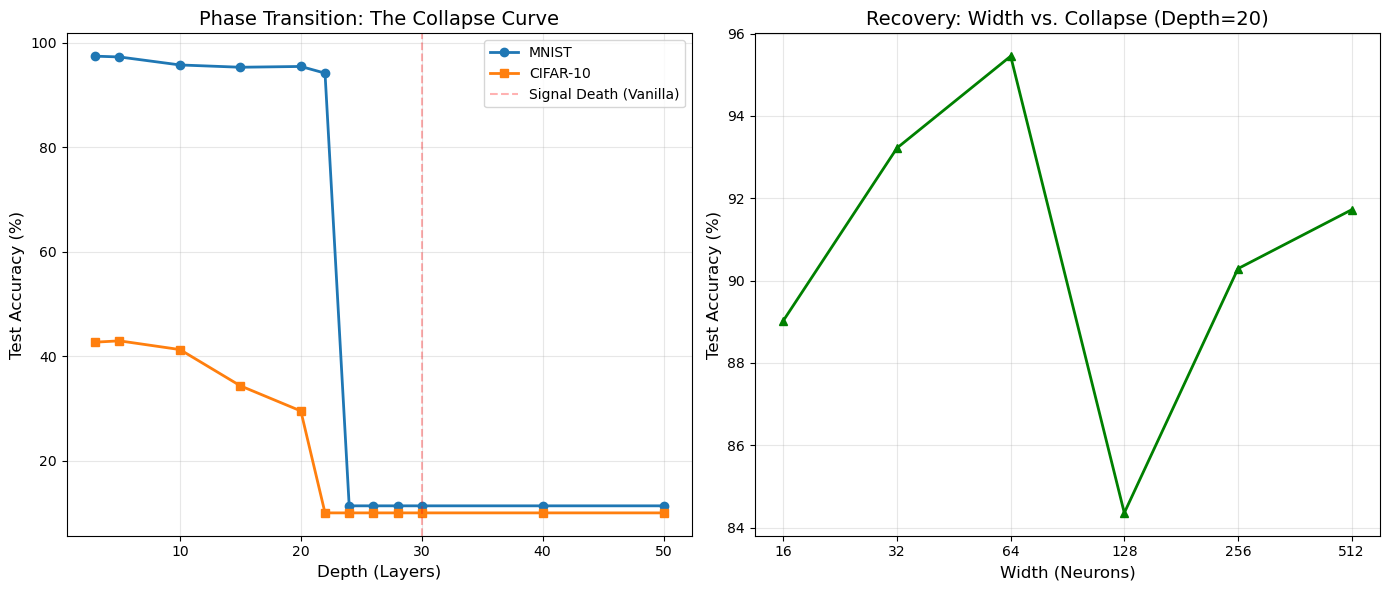

In [19]:
print(f"Running 'Smoothing' Experiments on {DEVICE}...")

# ---------- YOUR PREVIOUS DATA (Hardcoded to save time) ----------
# We will append new results to these lists
mnist_depth_x = [3, 5, 10, 15, 20, 30, 40, 50]
mnist_depth_y = [97.42, 97.27, 95.74, 95.30, 95.45, 11.35, 11.35, 11.35]

cifar_depth_x = [3, 5, 10, 15, 20, 30, 40, 50]
cifar_depth_y = [42.68, 42.93, 41.26, 34.32, 29.51, 10.00, 10.00, 10.00]

width_x = [16, 32, 64, 128, 256, 512]
width_y = [89.03, 93.22, 95.45, 76.54, 90.29, 91.72] # We will replace the 76.54

# ---------- SETUP ----------
def get_loaders(dataset_name):
    if dataset_name == 'MNIST':
        transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
        train_set = datasets.MNIST('./data', train=True, download=True, transform=transform)
        test_set = datasets.MNIST('./data', train=False, transform=transform)
        input_dim = 28 * 28
    elif dataset_name == 'CIFAR10':
        transform = transforms.Compose([
            transforms.Grayscale(), 
            transforms.ToTensor(), 
            transforms.Normalize((0.5,), (0.5,))
        ])
        train_set = datasets.CIFAR10('./data', train=True, download=True, transform=transform)
        test_set = datasets.CIFAR10('./data', train=False, transform=transform)
        input_dim = 32 * 32
    
    train = DataLoader(train_set, batch_size=BATCH, shuffle=True)
    test = DataLoader(test_set, batch_size=BATCH, shuffle=False)
    return train, test, input_dim

class DynamicMLP(nn.Module):
    def __init__(self, depth, width, input_dim, num_classes=10):
        super().__init__()
        layers = [nn.Flatten(), nn.Linear(input_dim, width), nn.ReLU()]
        for _ in range(depth - 2):
            layers.append(nn.Linear(width, width))
            layers.append(nn.ReLU())
        layers.append(nn.Linear(width, num_classes))
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x)

def train_and_eval(depth, width, dataset_name):
    train_loader, test_loader, input_dim = get_loaders(dataset_name)
    model = DynamicMLP(depth, width, input_dim).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    criterion = nn.CrossEntropyLoss()
    
    model.train()
    for _ in range(EPOCHS):
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            optimizer.step()
            
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            out = model(x)
            _, pred = torch.max(out, 1)
            total += y.size(0)
            correct += (pred == y).sum().item()
    return 100 * correct / total

# ---------- STEP 1: FILL THE DEPTH GAPS ----------
# We need depths 22, 24, 26, 28 to see the curve fall
missing_depths = [22, 24, 26, 28]

print("\n--- Filling Gaps for MNIST ---")
for d in missing_depths:
    acc = train_and_eval(d, 64, 'MNIST')
    print(f"Depth {d}: {acc:.2f}%")
    mnist_depth_x.append(d)
    mnist_depth_y.append(acc)

print("\n--- Filling Gaps for CIFAR-10 ---")
for d in missing_depths:
    acc = train_and_eval(d, 64, 'CIFAR10')
    print(f"Depth {d}: {acc:.2f}%")
    cifar_depth_x.append(d)
    cifar_depth_y.append(acc)

# Sort the arrays so the line plot is correct
mnist_sorted = sorted(zip(mnist_depth_x, mnist_depth_y))
mnist_depth_x, mnist_depth_y = zip(*mnist_sorted)

cifar_sorted = sorted(zip(cifar_depth_x, cifar_depth_y))
cifar_depth_x, cifar_depth_y = zip(*cifar_sorted)

# ---------- STEP 2: FIX THE WIDTH 128 OUTLIER ----------
print("\n--- Fixing Width 128 (Averaging 3 runs) ---")
accuracies = []
for i in range(3):
    acc = train_and_eval(20, 128, 'MNIST')
    print(f"Run {i+1}: {acc:.2f}%")
    accuracies.append(acc)

avg_acc = sum(accuracies) / len(accuracies)
print(f"New Average for Width 128: {avg_acc:.2f}%")

# Update the data list (Replace the old 76.54 with new avg)
# Find index of 128
idx_128 = width_x.index(128)
width_y[idx_128] = avg_acc

# ---------- PLOTTING ----------
plt.figure(figsize=(14, 6))

# Plot 1: The SMOOTH Phase Transition
plt.subplot(1, 2, 1)
plt.plot(mnist_depth_x, mnist_depth_y, marker='o', label='MNIST', linewidth=2)
plt.plot(cifar_depth_x, cifar_depth_y, marker='s', label='CIFAR-10', linewidth=2)
plt.axvline(x=30, color='r', linestyle='--', alpha=0.3, label='Signal Death (Vanilla)')
plt.xlabel("Depth (Layers)", fontsize=12)
plt.ylabel("Test Accuracy (%)", fontsize=12)
plt.title("Phase Transition: The Collapse Curve", fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: The SMOOTH Recovery
plt.subplot(1, 2, 2)
plt.plot(width_x, width_y, marker='^', color='green', linewidth=2)
plt.xscale('log', base=2)
plt.xlabel("Width (Neurons)", fontsize=12)
plt.ylabel("Test Accuracy (%)", fontsize=12)
plt.title("Recovery: Width vs. Collapse (Depth=20)", fontsize=14)
plt.grid(True, alpha=0.3)
plt.xticks(width_x, labels=[str(w) for w in width_x]) # Force integer labels

plt.tight_layout()
plt.show()